In [1]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("OASIS2.CSV")
print(df.columns)
print(df.head())

Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'],
      dtype='str')
  Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  


In [3]:
# Defining X and y variable
# Features and target
X = df[['MMSE','nWBV','Age']]
y = df['Group']

In [4]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Start time
start = time.time()


In [5]:
# Random Forest
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

start = time.time()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

end = time.time()

time_before = end - start
accuracy_before = accuracy_score(y_test, y_pred)

print("Accuracy before Dask:", accuracy_before)
print("Running time before Dask:", time_before)

Accuracy before Dask: 0.6666666666666666
Running time before Dask: 0.0793912410736084


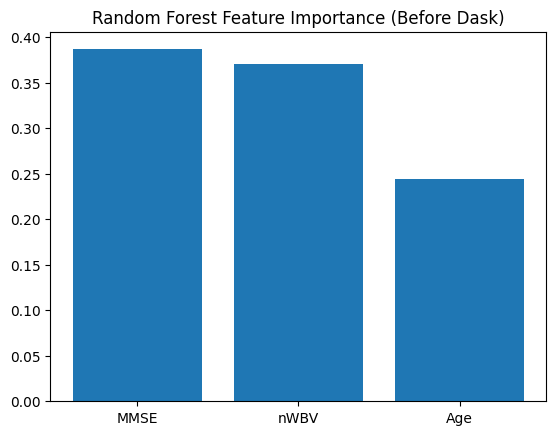

In [6]:
## Random forest graph before Dask

import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Random Forest Feature Importance (Before Dask)")
plt.show()

In [7]:
## Randon forest with Dask
import dask.dataframe as dd
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from dask_ml.model_selection import train_test_split

# Convert pandas dataframe to Dask dataframe
ddf = dd.from_pandas(df, npartitions=4)

# Features and target
X = ddf[['MMSE','nWBV','Age']]
y = ddf['Group']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Start timer
start = time.time()

# Train Random Forest
rf_dask = RandomForestClassifier(n_estimators=100, random_state=42)
rf_dask.fit(X_train.compute(), y_train.compute())

# Predictions
y_pred_dask = rf_dask.predict(X_test.compute())

# Stop timer
end = time.time()

# Calculate runtime
time_after = end - start

# Accuracy
accuracy_after = accuracy_score(y_test.compute(), y_pred_dask)

print("Accuracy after Dask:", accuracy_after)
print("Running time after Dask:", time_after)

Accuracy after Dask: 0.7301587301587301
Running time after Dask: 0.06836819648742676


/opt/anaconda3/envs/dask_env/lib/python3.11/site-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(


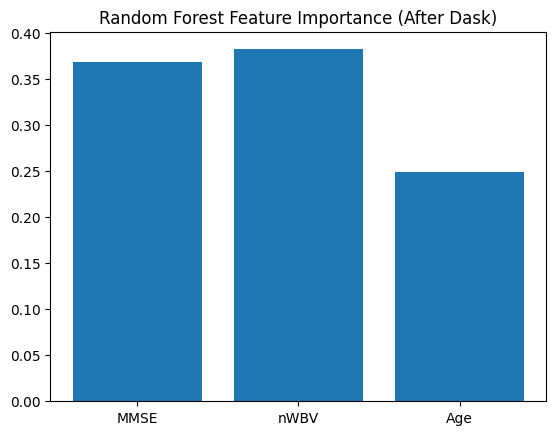

In [8]:
# Graph with dask
importances = rf_dask.feature_importances_

plt.bar(features, importances)
plt.title("Random Forest Feature Importance (After Dask)")
plt.show()

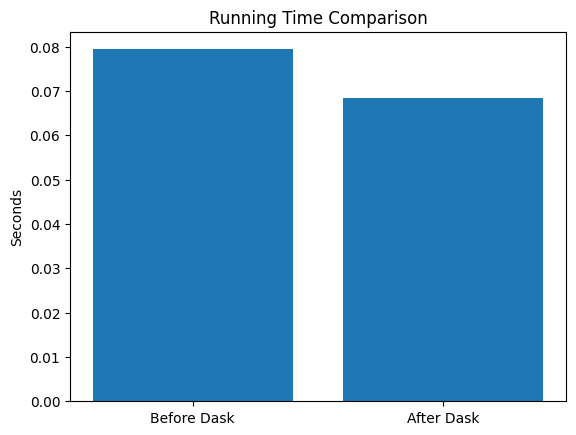

In [9]:
# create running time comparison graph
methods = ["Before Dask","After Dask"]
times = [time_before,time_after]

plt.bar(methods,times)
plt.title("Running Time Comparison")
plt.ylabel("Seconds")
plt.show()

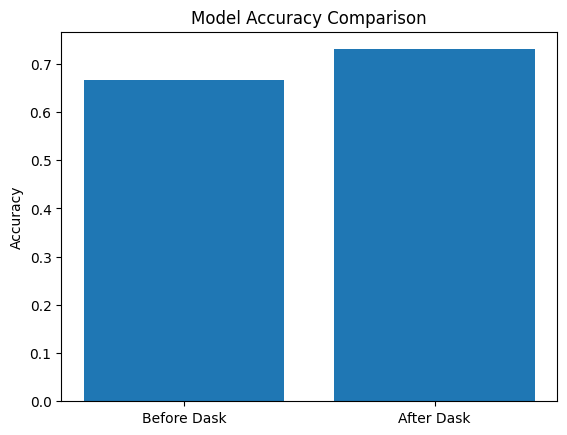

In [10]:
# create accuracy comparison graph
acc = [accuracy_before, accuracy_after]

plt.bar(methods, acc)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()